# Classification

## Overview

This notebook trains classical machine learning models for furniture sketch classification.

The previous notebook extracted HOG features from Canny sketch images. These features are now used as numerical input for classification models.

The main goal is to predict the furniture category from a sketch-like image representation. The first baseline model is Support Vector Machine (SVM), followed by additional classical machine learning models for comparison.

The classification task uses five furniture classes:

- bed
- chair
- dresser
- sofa
- table

The predefined train / validation / test split from the dataset is preserved throughout the experiment.

## Setup and Imports

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

sys.path.append("..")

%reload_ext autoreload
%autoreload 2

from src import utils

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded successfully")

Libraries loaded successfully


## Load Feature Arrays

The feature arrays created in Notebook 03 are loaded here.

`X_hog` contains the HOG feature matrix, where each row represents one sketch image and each column represents one HOG feature. The label array `y` contains the furniture class name for each image. The `splits` array preserves the predefined train, validation, and test split assignment. 

In [2]:
features_dir = utils.DATA_DIR / "features"

X_hog = np.load(features_dir / "X_hog.npy")
y = np.load(features_dir / "y.npy", allow_pickle=True)
splits = np.load(features_dir / "splits.npy", allow_pickle=True)
relative_paths = np.load(features_dir / "relative_paths.npy", allow_pickle=True)

print(f"X_hog shape: {X_hog.shape}")
print(f"y shape: {y.shape}")
print(f"splits shape: {splits.shape}")
print(f"relative_paths shape: {relative_paths.shape}")

X_hog shape: (2500, 8100)
y shape: (2500,)
splits shape: (2500,)
relative_paths shape: (2500,)


In [3]:
print(f"Feature matrix dtype: {X_hog.dtype}")
print(f"Classes: {sorted(np.unique(y))}")
print(f"Split values: {sorted(np.unique(splits))}")

Feature matrix dtype: float64
Classes: [np.str_('bed'), np.str_('chair'), np.str_('dresser'), np.str_('sofa'), np.str_('table')]
Split values: [np.str_('test'), np.str_('train'), np.str_('val')]


### Observation

The feature arrays from Notebook 03 were loaded successfully. The HOG feature matrix has shape (2500, 8100), matching 2,500 sketches with 8,100 features each. The label, split, and relative-path arrays are aligned with the feature matrix at 2,500 entries each.

The feature matrix is stored as `float64`, the five furniture classes are present, and all three split values (`train`, `val`, `test`) are available. The data is intact and ready to be divided into training, validation, and test matrices.

## Create Train / Validation / Test Matrices

The predefined split information is used to create separate train, validation, and test matrices.

The training set is used to fit the model. The validation set is used to evaluate model performance during development and compare models. The test set is kept separate for final evaluation.

In [4]:
train_mask = splits == "train"
val_mask = splits == "val"
test_mask = splits == "test"

X_train, y_train = X_hog[train_mask], y[train_mask]
X_val, y_val = X_hog[val_mask], y[val_mask]
X_test, y_test = X_hog[test_mask], y[test_mask]

print(f"Train: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

print(f"\nTrain class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

Train: 1750 samples
Val:   375 samples
Test:  375 samples

Train class distribution:
bed        350
chair      350
dresser    350
sofa       350
table      350
Name: count, dtype: int64


In [5]:
print("Validation class distribution:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Validation class distribution:
bed        75
chair      75
dresser    75
sofa       75
table      75
Name: count, dtype: int64

Test class distribution:
bed        75
chair      75
dresser    75
sofa       75
table      75
Name: count, dtype: int64


The dataset was split successfully into training, validation, and test subsets. The prototype dataset remains balanced across all five furniture classes, with 350 training samples, 75 validation samples, and 75 test samples per class.

This balance is useful because accuracy and macro F1-score can be interpreted more clearly when each class has the same number of samples in each split.

## Evaluation Metrics

Accuracy and macro F1-score are used as the main evaluation metrics.

Accuracy measures the overall proportion of correctly classified images.

Macro F1-score calculates the F1-score independently for each class and then averages the scores equally across all classes. This is useful for multi-class classification because each furniture category contributes equally to the final score.

In [7]:
def evaluate_classifier(model, X_eval, y_eval, model_name="Model"):
    """
    Evaluate a trained classifier using accuracy, macro F1-score,
    and a full classification report.
    """
    y_pred = model.predict(X_eval)

    accuracy = accuracy_score(y_eval, y_pred)
    macro_f1 = f1_score(y_eval, y_pred, average="macro")

    print(f"{model_name} evaluation")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1-score: {macro_f1:.4f}")
    print("\nClassification report:")
    print(classification_report(y_eval, y_pred, zero_division=0))

    return {
        "model": model_name,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "y_pred": y_pred,
    }

## Baseline Model: SVM

Support Vector Machine is used as the first baseline classifier.

SVM is a suitable starting model because HOG features are high-dimensional numerical descriptors, and SVMs often perform well with this type of feature representation.

A `StandardScaler` is used before the classifier because SVM models are sensitive to feature scale.

In [8]:
%%time

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        random_state=utils.RANDOM_STATE
    )),
])

svm_model.fit(X_train, y_train)

print("SVM model trained successfully")

SVM model trained successfully
CPU times: total: 1min 24s
Wall time: 22.9 s


In [9]:
svm_val_results = evaluate_classifier(
    svm_model,
    X_val,
    y_val,
    model_name="SVM validation"
)

SVM validation evaluation
Accuracy: 0.7653
Macro F1-score: 0.7689

Classification report:
              precision    recall  f1-score   support

         bed       0.83      0.67      0.74        75
       chair       0.59      0.85      0.70        75
     dresser       0.92      0.81      0.87        75
        sofa       0.76      0.81      0.79        75
       table       0.85      0.68      0.76        75

    accuracy                           0.77       375
   macro avg       0.79      0.77      0.77       375
weighted avg       0.79      0.77      0.77       375



### Observation

The first SVM baseline achieved a validation accuracy of **0.7653** and a macro F1-score of **0.7689**.

This result confirms that the pipeline is working: HOG features extracted from Canny sketch images contain enough shape information for classical machine learning classification.

The strongest class is `dresser`, with an F1-score of **0.87**. This is likely because dressers often contain distinctive rectangular outlines and drawer structures. The weakest class is `chair`, with an F1-score of **0.70**. Chair precision is lower than recall, meaning that the model often predicts other furniture sketches as chairs.

Overall, the SVM baseline provides a solid first result for the prototype dataset.

## SVM Confusion Matrix

The confusion matrix shows which furniture classes are predicted correctly and which classes are confused with each other.

Rows represent the true labels, and columns represent the predicted labels.

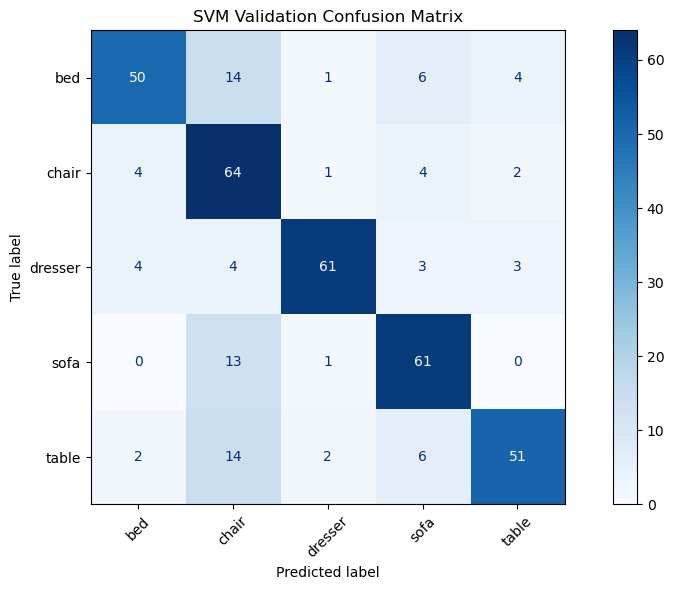

Figure saved to: C:\Users\Vanya\PycharmProjects\PythonProject\SoftUni-Studies\Furniture-Sketch-Classifier\outputs\figures\svm_validation_confusion_matrix.png


In [10]:
labels = sorted(np.unique(y))

cm = confusion_matrix(
    y_val,
    svm_val_results["y_pred"],
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("SVM Validation Confusion Matrix")
plt.tight_layout()

fig_path = utils.FIGURES_DIR / "svm_validation_confusion_matrix.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {fig_path}")

### Observation

The confusion matrix confirms the validation results from the classification report.

The model correctly classifies many examples from each class. `Dresser` and `sofa` show strong diagonal values, meaning most of their samples are classified correctly. The distinctive drawer-grid structure of dressers makes them especially separable.

The main confusion pattern is that several classes are sometimes predicted as `chair` (14 beds, 13 sofas, 14 tables, and 4 dressers). This matches the classification report, where `chair` had high recall but low precision. The most frequent specific error is `sofa` predicted as `chair`, which is intuitive: sofas and chairs share similar edge structures such as a seat, back, arms, and legs, and these become difficult to separate from contour information alone.

The `bed` class shows more scattered misclassifications, spread across chair, sofa, and table. This is consistent with the intra-class variation identified in Notebook 01, where the `bed` category contains several visually different subtypes such as platform, canopy, daybed, and bunk beds.

Overall, the errors are concentrated and structurally explainable rather than random, which suggests the SVM baseline is learning genuine shape patterns. This provides a solid first result for the sketch classification pipeline.

## Additional Classical ML Models

## Model Comparison

## Best Model Selection

## Final Test Evaluation

## Save Results

## Error Analysis Preparation

## Summary and Next Steps